In [1]:
# security simulation for PoS mining
# goal: analyze attack feasibility based on stake concentration
import numpy as np
import matplotlib.pyplot as plt

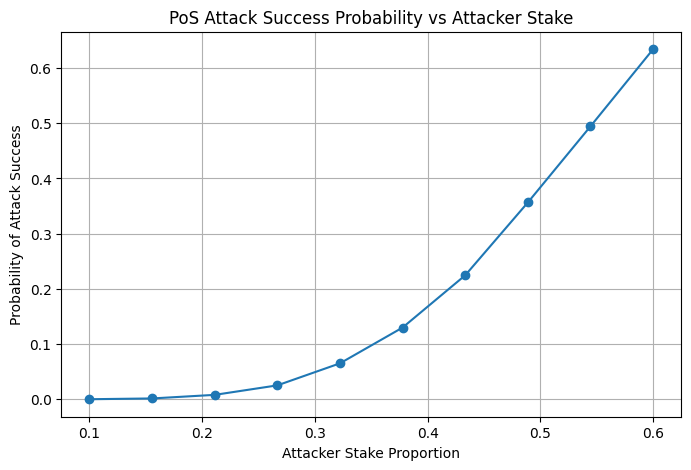

In [ ]:
# v1 simulation
# ignores blockchain history/chain growth/validator selection based on stake

def simulate_pos_attack(num_validators=10000, attack_stake=0.3, num_simulations=10000):
    """
    Simulates attack probability in a PoS system.
    - num_validators: Number of total validators in the network.
    - attack_stake: Fraction of total stake controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    stake_distribution = np.ones(num_validators) / num_validators
    num_attackers = int(num_validators * attack_stake)
    stake_distribution[:num_attackers] = attack_stake / num_attackers
    stake_distribution[num_attackers:] = (1 - attack_stake) / (num_validators - num_attackers)
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        selected_validators = np.random.choice(range(num_validators), size=10, p=stake_distribution, replace=True)
        
        if np.sum(selected_validators < num_attackers) > 5:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

attack_stakes = np.linspace(0.1, 0.6, 10)
attack_probs = [simulate_pos_attack(attack_stake=stake) for stake in attack_stakes]

plt.figure(figsize=(8, 5))
plt.plot(attack_stakes, attack_probs, marker='o', linestyle='-')
plt.xlabel('Attacker Stake Proportion')
plt.ylabel('Probability of Attack Success')
plt.title('PoS Attack Success Probability vs Attacker Stake')
plt.show()

In [ ]:
# next todo: compare this to PoW attack probability
# sustainabilty of PoS

# if we assume num_validators is 10000 we have
num_validators = 10000
energy_per_txn = 50 #kWh; assume 15 transactions per second 
#https://www.bitwave.io/blog/is-proof-of-stake-really-more-energy-efficient-than-proof-of-work#:~:text=Ethereum%20can%20conduct%20around%2015,or%20sourcing%20large%20energy%20supplies.”

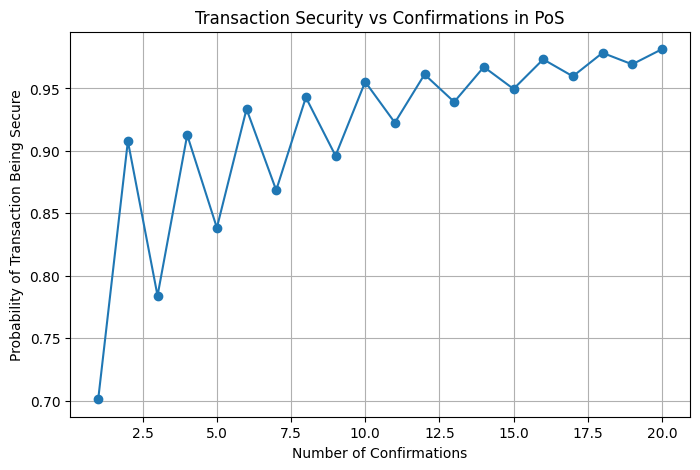

In [7]:
def simulate_transaction_security(num_confirmations=10, attack_stake=0.3, num_simulations=10000):
    """
    Simulates the probability that a transaction remains irreversible after a given number of confirmations.
    - num_confirmations: Number of blocks added after the transaction.
    - attack_stake: Fraction of total stake controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attack_stake)
        
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

confirmations = np.arange(1, 21)
security_probs = [1 - simulate_transaction_security(num_confirmations=n) for n in confirmations]

plt.figure(figsize=(8, 5))
plt.plot(confirmations, security_probs, marker='o', linestyle='-')
plt.xlabel('Number of Confirmations')
plt.ylabel('Probability of Transaction Being Secure')
plt.title('Transaction Security vs Confirmations in PoS')
plt.grid()
plt.show()

Beta = 0.10, Blockchain Secure: True


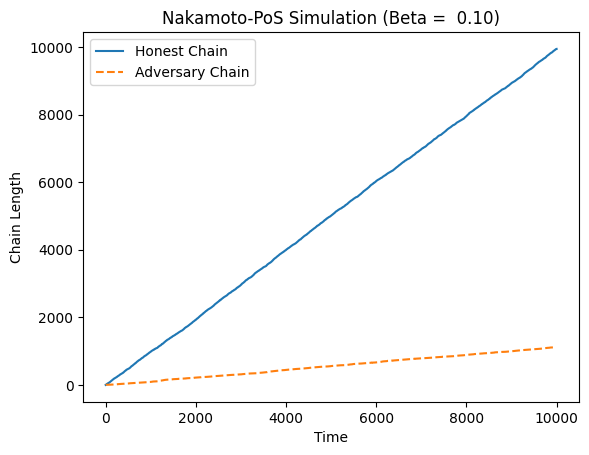

Beta = 0.20, Blockchain Secure: True


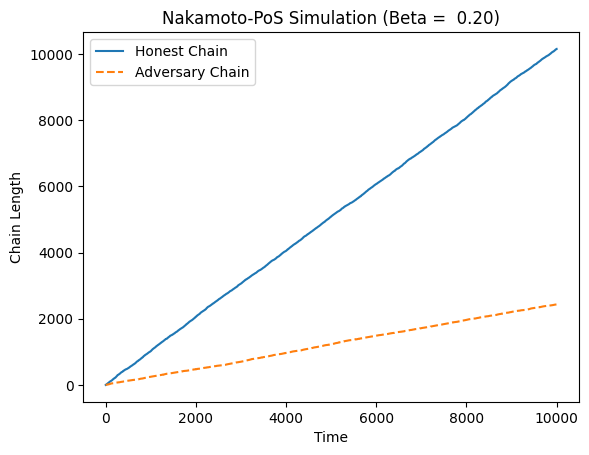

Beta = 0.30, Blockchain Secure: True


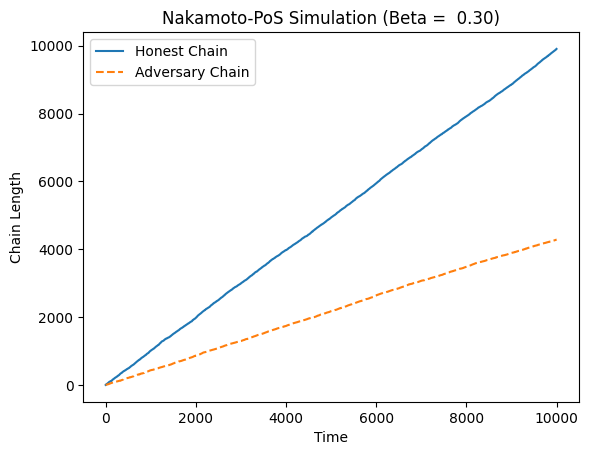

Beta = 0.40, Blockchain Secure: True


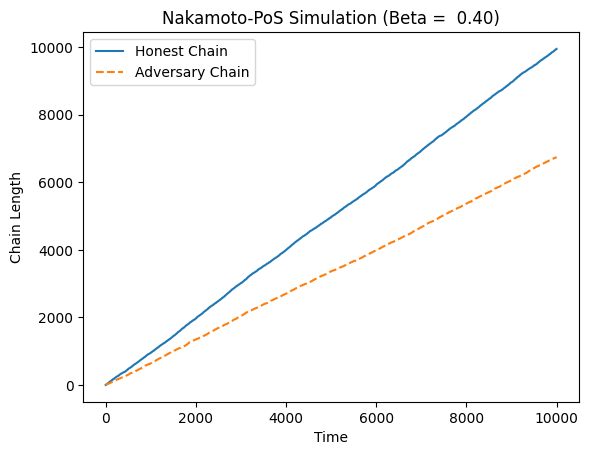

Beta = 0.50, Blockchain Secure: True


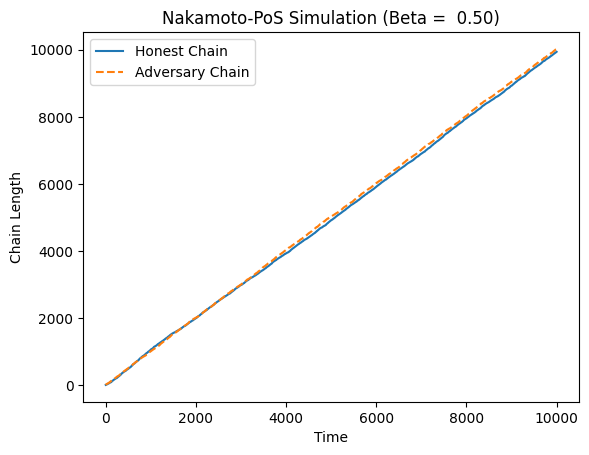

In [ ]:
# Updated sim: Poisson process; Nakamoto PoS simulation
# Based on paper
class NakamotoPoS:
    def __init__(self, beta, lambda_h=1, T=10000):
        """
        Simulates a Nakamoto-PoS blockchain
        :param beta: Fraction of stake controlled by adversary
        :param lambda_h: Block generation rate of honest nodes (Poisson process rate)
        :param T: Simulation time steps
        """
        self.beta = beta
        self.lambda_h = lambda_h
        self.lambda_a = beta * lambda_h / (1 - beta)  # Adversary block rate
        self.T = T
        self.honest_chain = 0  # Honest chain length
        self.adversary_chain = 0  # Adversary's private chain length
        self.honest_blocks = []
        self.adversary_blocks = []
        self.time = 0
        
    def run_simulation(self):
        """Simulates Nakamoto-PoS block production and adversarial growth."""
        while self.time < self.T:
            # Generate next block times
            honest_time = np.random.exponential(1 / self.lambda_h)
            adversary_time = np.random.exponential(1 / self.lambda_a)
            
            if honest_time < adversary_time:
                self.honest_chain += 1
                self.honest_blocks.append(self.time + honest_time)
                self.time += honest_time
                self.resolve_fork()
            else:
                self.adversary_chain += 1
                self.adversary_blocks.append(self.time + adversary_time)
                self.time += adversary_time
                self.resolve_fork()
        
    def resolve_fork(self):
        """Resolves forks based on longest chain rule."""
        if self.adversary_chain > self.honest_chain:
            self.honest_chain = self.adversary_chain
        elif self.honest_chain > self.adversary_chain:
            self.adversary_chain = self.honest_chain
    
    def is_secure(self):
        """Checks if the blockchain remained secure (i.e., honest chain dominated)."""
        # print("Length of honest chain: ", self.honest_chain)
        # print("Length of adversary chain: ", self.adversary_chain)
        return self.honest_chain >= self.adversary_chain
    
    def plot_results(self):
        """Plots the chain growth over time."""
        plt.plot(self.honest_blocks, range(1, len(self.honest_blocks) + 1), label='Honest Chain')
        plt.plot(self.adversary_blocks, range(1, len(self.adversary_blocks) + 1), label='Adversary Chain', linestyle='dashed')
        plt.xlabel('Time')
        plt.ylabel('Chain Length')
        plt.title(f'Nakamoto-PoS Simulation (Beta = {self.beta: .2f})')
        plt.legend()
        plt.show()
        
# Run simulations for different adversarial stakes
betas = np.linspace(0.1, 0.5, 5)  # Test beta from 10% to 50%
for beta in betas:
    simulation = NakamotoPoS(beta=beta, T=10000)
    simulation.run_simulation()
    secure = simulation.is_secure()
    print(f'Beta = {beta:.2f}, Blockchain Secure: {secure}')
    simulation.plot_results()

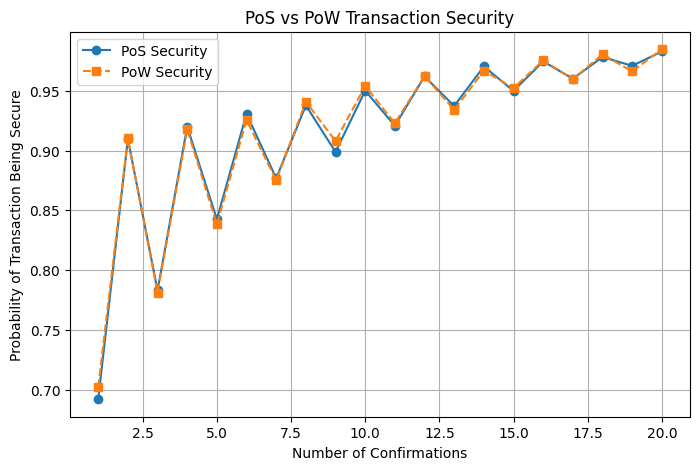

In [19]:
# comparing to PoW
def simulate_transaction_security(num_confirmations=10, attack_stake=0.3, num_simulations=10000):
    """
    Simulates the probability that a transaction remains irreversible after a given number of confirmations.
    - num_confirmations: Number of blocks added after the transaction.
    - attack_stake: Fraction of total stake controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attack_stake)
        
        # If the attacker controls more than half of the confirmations, they can reorganize the chain
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

# Simulating transaction security for different confirmation levels
confirmations = np.arange(1, 21)
pos_security_probs = [1 - simulate_transaction_security(num_confirmations=n) for n in confirmations]

def simulate_pow_transaction_security(num_confirmations=10, attacker_hashrate=0.3, num_simulations=10000):
    """
    Simulates the probability that a PoW transaction remains irreversible after a given number of confirmations.
    - num_confirmations: Number of blocks added after the transaction.
    - attacker_hashrate: Fraction of total network hash power controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attacker_hashrate)
        
        # If the attacker controls more than half of the confirmations, they can reorganize the chain
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

# Simulating PoW security
pow_security_probs = [1 - simulate_pow_transaction_security(num_confirmations=n) for n in confirmations]

# Plot PoS vs PoW transaction security
plt.figure(figsize=(8, 5))
plt.plot(confirmations, pos_security_probs, marker='o', linestyle='-', label='PoS Security')
plt.plot(confirmations, pow_security_probs, marker='s', linestyle='--', label='PoW Security')
plt.xlabel('Number of Confirmations')
plt.ylabel('Probability of Transaction Being Secure')
plt.title('PoS vs PoW Transaction Security')
plt.legend()
plt.grid()
plt.show()

In [1]:
import math
from scipy.stats import poisson
from scipy.optimize import brentq

def pow_attack_probability(q, z):
    """
    Computes the probability of a successful attack in a Proof-of-Work system.
    
    Parameters:
      q (float): The fraction of the total hash power controlled by the attacker (0 < q < 1).
      z (int): The number of confirmation blocks (i.e., the honest chain is z blocks ahead).

    Returns:
      float: The probability that an attacker with mining power q eventually catches up.
      
    Notes:
      - p is the fraction of honest miners, defined as p = 1 - q.
      - If q >= 0.5, the attacker eventually wins with probability 1.
      - Otherwise, the function uses the Poisson distribution with mean lambda = z * (q / p).
    """
    if q >= 0.5:
        return 1.0

    p = 1 - q
    lam = z * (q / p)
    probability = 0.0

    # Sum over k = 0 to z-1 using the Poisson probability mass function (pmf)
    for k in range(z):
        pk = poisson.pmf(k, lam)
        probability += pk * ((q / p) ** (z - k))
    
    # Add the tail probability for k >= z (attacker finds at least z blocks)
    probability += 1 - poisson.cdf(z - 1, lam)
    
    return probability

def find_required_hash_power(z, target_prob, q_lower=0.001, q_upper=0.499):
    """
    Finds the minimum attacker hash power (q) required such that the probability
    of a successful attack is at least the target probability, given confirmation depth z.
    
    Parameters:
      z (int): The confirmation depth.
      target_prob (float): The target attack success probability.
      q_lower (float): The lower bound for q in the root finding.
      q_upper (float): The upper bound for q in the root finding.
    
    Returns:
      float: The attacker hash power fraction q that meets the target probability.
    """
    # Define the function whose root we want to find:
    # f(q) = attack_probability(q, z) - target_prob
    def f(q):
        return pow_attack_probability(q, z) - target_prob

    # Use brentq to find the root in the interval [q_lower, q_upper]
    q_required = brentq(f, q_lower, q_upper)
    return q_required

z = 6
target_probability = 0.1

q_required = find_required_hash_power(z, target_probability)
computed_probability = pow_attack_probability(q_required, z)

print("For a confirmation depth of {} blocks:".format(z))
print("  The required attacker hash power to reach a success probability of {:.2%} is approximately: {:.2%}".format(target_probability, q_required))
print("  Confirmed computed attack probability: {:.2%}".format(computed_probability))


For a confirmation depth of 6 blocks:
  The required attacker hash power to reach a success probability of 10.00% is approximately: 28.44%
  Confirmed computed attack probability: 10.00%


In [2]:
import math
from scipy.optimize import brentq

def pos_attack_probability(q, z):
    """
    Computes the probability of a successful attack in a Proof-of-Stake system.
    
    For an attacker with stake fraction q, the probability to catch up from a deficit
    of z blocks is given by (q/(1-q))^z for q < 0.5. For q >= 0.5, we assume the attacker
    eventually succeeds (i.e., probability = 1).
    
    Parameters:
      q (float): The fraction of the total stake held by the attacker.
      z (int): The number of confirmation blocks (i.e., the honest chain is z blocks ahead).
    
    Returns:
      float: The attack success probability.
    """
    if q >= 0.5:
        return 1.0
    return (q / (1 - q)) ** z

def find_required_stake(z, target_prob, q_lower=1e-6, q_upper=0.5):
    """
    Finds the minimum attacker stake (q) required such that the attack success probability 
    is equal to the target probability for a given confirmation depth z.
    
    Parameters:
      z (int): The confirmation depth (number of blocks the attacker is behind).
      target_prob (float): The target success probability for the attack.
      q_lower (float): Lower bound for search (should be >0).
      q_upper (float): Upper bound for search (should be <=0.5, as q>=0.5 implies probability 1).
    
    Returns:
      float: The minimum attacker stake fraction q that results in the target probability.
    """
    # Define the function whose root we want to find:
    # f(q) = pos_attack_probability(q, z) - target_prob
    def f(q):
        return pos_attack_probability(q, z) - target_prob

    # Find q such that f(q) == 0 using brentq
    q_required = brentq(f, q_lower, q_upper)
    return q_required

z = 6                   # For instance, the honest chain is 6 blocks ahead
target_probability = 0.1  # We want the attacker to have a 10% chance to catch up

q_required = find_required_stake(z, target_probability)
computed_probability = pos_attack_probability(q_required, z)

print("For a confirmation depth of {} blocks:".format(z))
print("  The required attacker stake to reach a success probability of {:.2%} is approximately: {:.2%}".format(target_probability, q_required))
print("  Confirmed computed attack probability: {:.2%}".format(computed_probability))


For a confirmation depth of 6 blocks:
  The required attacker stake to reach a success probability of 10.00% is approximately: 40.52%
  Confirmed computed attack probability: 10.00%


In [3]:
import math
from scipy.stats import poisson
from scipy.optimize import brentq

def pow_attack_probability(q, z):
    """
    Computes the probability of a successful attack in a Proof-of-Work system,
    following the model from the Bitcoin whitepaper.
    
    Parameters:
      q (float): The attacker's fraction of the total hash rate (0 < q < 1).
      z (int): The confirmation depth (number of blocks the attacker is behind).
    
    Returns:
      float: The probability that an attacker eventually catches up.
    """
    if q >= 0.5:
        return 1.0
    p = 1 - q
    lam = z * (q / p)
    probability = 0.0
    # Sum over k = 0 to z-1 blocks the attacker might find
    for k in range(z):
        probability += poisson.pmf(k, lam) * ((q / p) ** (z - k))
    # Add the tail probability for k >= z (attacker finds at least z blocks)
    probability += 1 - poisson.cdf(z - 1, lam)
    return probability

def find_minimum_network_hashrate(A, z, P_target, H_lower=None, H_upper=None):
    """
    Determines the minimal network hash rate H (in hashes/second) such that the attack probability,
    given an attacker with maximum hash rate A, is at or below a target value.
    
    Here, the attacker's fraction is q = A/H, so the condition is:
      pow_attack_probability(A/H, z) <= P_target
    
    Parameters:
      A (float): The attacker's maximum hash rate (hashes per second), derived from their energy budget.
      z (int): Confirmation depth (number of blocks).
      P_target (float): The maximum acceptable probability of a successful attack.
      H_lower (float): Lower bound for H in the root-finding (defaults to slightly above A).
      H_upper (float): Upper bound for H (defaults to A * 1000).
    
    Returns:
      float: The minimal network hash rate H_opt required to meet the security target.
    """
    # Define the function to find the root for:
    # f(H) = pow_attack_probability(A/H, z) - P_target
    def f(H):
        return pow_attack_probability(A / H, z) - P_target

    # Lower bound: H must be larger than A so that q = A/H < 1.
    if H_lower is None:
        H_lower = A * 1.001  # just a bit above A
    if H_upper is None:
        H_upper = A * 1000   # choose a sufficiently high upper bound

    # Use brentq to find the network hash rate H such that f(H) == 0.
    H_opt = brentq(f, H_lower, H_upper)
    return H_opt


attacker_power = 1000  # in watts (J/s)
energy_per_hash = 1e-9  # joules per hash

# The attacker's maximum sustainable hash rate (hashes per second):
A = attacker_power / energy_per_hash

z = 6            # Confirmation depth (e.g., 6 blocks)
P_target = 0.1   # Target maximum attack probability (10%)

# Find the minimum network hash rate required:
H_opt = find_minimum_network_hashrate(A, z, P_target)

# Compute the corresponding energy consumption of the network per second.
# (Assuming the same energy efficiency as the attacker.)
network_energy_consumption = H_opt * energy_per_hash  # in watts

print("Attacker's maximum hash rate: {:.2e} hashes/s".format(A))
print("Optimal network hash rate to ensure attack probability <= {:.0%}: {:.2e} hashes/s".format(P_target, H_opt))
print("Corresponding network energy consumption: {:.2f} watts".format(network_energy_consumption))


Attacker's maximum hash rate: 1.00e+12 hashes/s
Optimal network hash rate to ensure attack probability <= 10%: 3.52e+12 hashes/s
Corresponding network energy consumption: 3516.34 watts


In [5]:
import math
from scipy.optimize import brentq

def pos_attack_probability(q, z):
    """
    Computes the probability of a successful attack in a Proof-of-Stake system.
    
    For an attacker with stake fraction q, the chance to catch up from a deficit
    of z blocks is given by (q/(1-q))^z (for q < 0.5). For q >= 0.5, returns 1.
    
    Parameters:
      q (float): Attacker's fraction of the total stake.
      z (int): Number of confirmation blocks (i.e., the honest chain is z blocks ahead).
    
    Returns:
      float: The attack success probability.
    """
    if q >= 0.5:
        return 1.0
    return (q / (1 - q)) ** z

def find_minimum_total_stake(A, z, P_target, S_lower=None, S_upper=None):
    """
    Determines the minimal total staked amount S required so that, with an attacker having
    available stake A, the attack probability is at or below P_target.
    
    Here, the attacker's stake fraction is q = A/S. We solve:
      pos_attack_probability(A/S, z) = P_target.
    
    Parameters:
      A (float): Attacker's available stake (e.g., in tokens).
      z (int): Confirmation depth (number of blocks behind).
      P_target (float): The target maximum attack probability.
      S_lower (float): Lower bound for S (defaults to just above 2*A, so that A/S < 0.5).
      S_upper (float): Upper bound for S (defaults to a large multiple of A).
    
    Returns:
      float: The minimal total staked amount S that meets the security target.
    """
    def f(S):
        return pos_attack_probability(A / S, z) - P_target

    if S_lower is None:
        S_lower = A * 2.001  # ensures q = A/S < 0.5
    if S_upper is None:
        S_upper = A * 1000.0  # arbitrary high upper bound

    S_opt = brentq(f, S_lower, S_upper)
    return S_opt

def network_energy_per_transaction(n_transactions, energy_per_tx=15):
    """
    Computes the total energy consumption for a given number of transactions,
    assuming a fixed energy cost per transaction.
    
    Parameters:
      n_transactions (int): Number of transactions processed.
      energy_per_tx (float): Energy cost per transaction (in kWh), default is 15.
    
    Returns:
      float: Total energy consumption in kWh.
    """
    return n_transactions * energy_per_tx


A = 1000.0      # Attacker's available stake in tokens
z = 6           # Confirmation depth (e.g., 6 blocks)
P_target = 0.1  # Target maximum attack probability (10%)

# Find the minimum total stake S required to achieve the security target.
S_opt = find_minimum_total_stake(A, z, P_target)
computed_attack_prob = pos_attack_probability(A / S_opt, z)

# Energy usage in PoS:
# We assume that each transaction consumes 15 kWh.
n_tx = 10000  # example: processing 10,000 transactions
total_energy = network_energy_per_transaction(n_tx)

print("Proof-of-Stake Security Parameters:")
print(f"  Attacker's available stake: {A:.2f} tokens")
print(f"  Minimum total staked required for P_attack ≤ {P_target:.0%}: {S_opt:.2f} tokens")
print(f"  Computed attack probability: {computed_attack_prob:.2%}\n")

print("Energy Usage in PoS:")
print("  Assumed energy per transaction: 15 kWh")
print(f"  Total energy for {n_tx} transactions: {total_energy} kWh")


Proof-of-Stake Security Parameters:
  Attacker's available stake: 1000.00 tokens
  Minimum total staked required for P_attack ≤ 10%: 2467.80 tokens
  Computed attack probability: 10.00%

Energy Usage in PoS:
  Assumed energy per transaction: 15 kWh
  Total energy for 10000 transactions: 150000 kWh


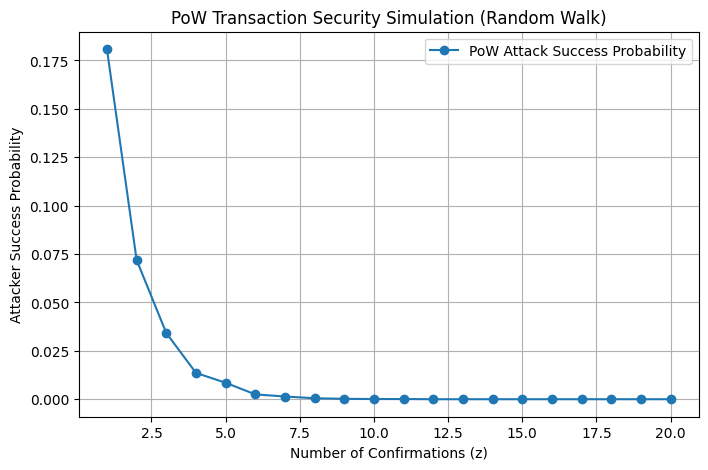

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_pow_random_walk(z, attacker_hashrate, num_simulations=10000, cutoff=100):
    """
    Simulate the probability that an attacker (with fraction attacker_hashrate) can catch up
    from a starting deficit of z blocks using a random walk model.
    
    Parameters:
      z: number of confirmations (initial gap)
      attacker_hashrate: fraction of total hash power controlled by the attacker (q)
      num_simulations: number of Monte Carlo runs
      cutoff: if the gap grows beyond this value, we assume the attacker will never catch up.
    
    Returns:
      Probability that the attacker eventually catches up.
    """
    p = 1 - attacker_hashrate  # honest miners' fraction
    successes = 0
    
    for _ in range(num_simulations):
        diff = z  # start with z blocks behind
        # Continue simulation until the attacker catches up (diff < 0)
        # or the gap becomes so large that catching up is virtually impossible.
        while diff >= 0 and diff < cutoff:
            # In each step, one block is found by either the honest network or the attacker.
            if np.random.rand() < p:
                diff += 1  # honest network finds a block → gap widens by 1
            else:
                diff -= 1  # attacker finds a block → gap shrinks by 1
        if diff < 0:
            successes += 1

    return successes / num_simulations

# Now we can simulate the PoW security for various confirmation depths:
confirmations = np.arange(1, 21)
attacker_hashrate = 0.3  # e.g., attacker controls 30% of total hash power
pow_security_probs = [simulate_pow_random_walk(z, attacker_hashrate) for z in confirmations]

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(confirmations, pow_security_probs, marker='o', linestyle='-', label='PoW Attack Success Probability')
plt.xlabel('Number of Confirmations (z)')
plt.ylabel('Attacker Success Probability')
plt.title('PoW Transaction Security Simulation (Random Walk)')
plt.legend()
plt.grid(True)
plt.show()


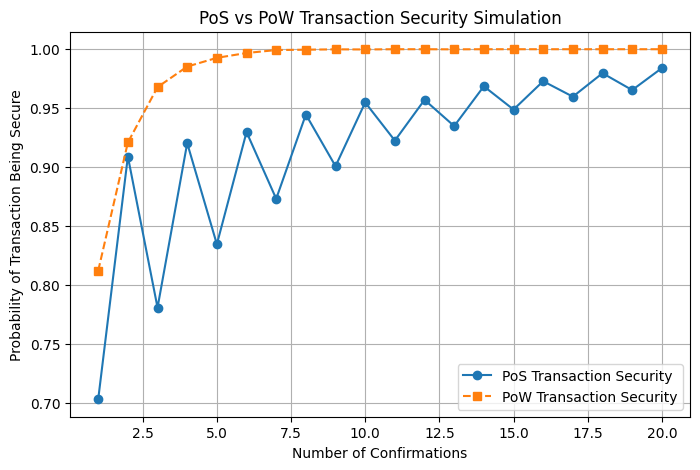

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_pos_security(num_confirmations=10, attack_stake=0.3, num_simulations=10000):
    """
    Simulate PoS transaction security by treating block production as independent coin flips.
    Returns the probability that an attacker successfully reorganizes the chain.
    """
    attack_success_count = 0
    for _ in range(num_simulations):
        # For each confirmation, attacker wins with probability attack_stake.
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attack_stake)
        # If the attacker "wins" more than half of the confirmations,
        # they could reorganize the chain.
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1
    return attack_success_count / num_simulations

def simulate_pow_random_walk(z, attacker_hashrate=0.3, num_simulations=10000, cutoff=100):
    """
    Simulate PoW transaction security using a random walk model.
    The simulation starts with a deficit of z blocks (the number of confirmations).
    At each step, the gap increases by 1 if the honest network finds a block (probability 1 - attacker_hashrate)
    or decreases by 1 if the attacker finds a block (probability attacker_hashrate).
    The attacker succeeds if the gap becomes negative.
    A cutoff is used to end simulations where the gap grows so large that catching up is virtually impossible.
    Returns the probability that the attacker eventually catches up.
    """
    p = 1 - attacker_hashrate  # probability that an honest miner finds the next block
    successes = 0
    for _ in range(num_simulations):
        diff = z  # start with a deficit of z blocks
        while diff >= 0 and diff < cutoff:
            # Simulate the next block event.
            if np.random.rand() < p:
                diff += 1  # honest network extends the chain
            else:
                diff -= 1  # attacker finds a block, reducing the gap
        if diff < 0:
            successes += 1
    return successes / num_simulations

# Define a range for the number of confirmations.
confirmations = np.arange(1, 21)

# Simulate attack success probability for PoS and PoW.
pos_attack_prob = [simulate_pos_security(num_confirmations=n, attack_stake=0.3, num_simulations=10000) for n in confirmations]
pow_attack_prob = [simulate_pow_random_walk(z, attacker_hashrate=0.3, num_simulations=10000, cutoff=100) for z in confirmations]

# Convert these into transaction security probabilities.
pos_security = [1 - prob for prob in pos_attack_prob]
pow_security = [1 - prob for prob in pow_attack_prob]

# Plot the results.
plt.figure(figsize=(8, 5))
plt.plot(confirmations, pos_security, marker='o', linestyle='-', label='PoS Transaction Security')
plt.plot(confirmations, pow_security, marker='s', linestyle='--', label='PoW Transaction Security')
plt.xlabel('Number of Confirmations')
plt.ylabel('Probability of Transaction Being Secure')
plt.title('PoS vs PoW Transaction Security Simulation')
plt.legend()
plt.grid(True)
plt.show()
